# Overview
Exploratory analysis of customer shopping behavior across 10 Istanbul malls.

- [Data Validation](#Data-Validation) — checks for missing values, duplicates, and bogus entries
- [Gender Distribution](#Gender-Distribution) — customer split by gender
- [Time-Based Sales](#Time-Based-Sales) — monthly sales trends per mall
- [Category Distribution](#Category-Distribution) — most purchased product categories
- [Gender & Category](#Gender-and-Category-Analysis) — buying behavior across genders
- [Age Group Analysis](#Age-Group-Analysis) — revenue, preferences, and gender breakdown by age
- [Key Insights](#Key-Insights) — data-backed conclusions drawn from the analysis

#### Importing Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Loading Data

In [2]:
sales_df = pd.read_csv('customer_shopping_data.csv')
sales_df.drop(columns='invoice_no', inplace=True)

#### Data Inspection

In [58]:
sales_df.head()

,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,age_group
0,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,20-29
1,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,20-29
2,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,20-29
3,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,60-69
4,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,50-59


In [59]:
sales_df.dtypes

customer_id                  str
gender                       str
age                        int64
category                     str
quantity                   int64
price                    float64
payment_method               str
invoice_date      datetime64[us]
shopping_mall                str
age_group               category
dtype: object

## Data Validation

#### Duplicate Check

In [4]:
sales_df.duplicated().sum()

0

#### Null and Bogus Value Check

In [60]:
sales_df.isnull().sum()

customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
age_group         0
dtype: int64

In [66]:
for col in ['gender', 'category', 'payment_method', 'shopping_mall']:
    print(f"\n{col}: {sales_df[col].unique()}")


gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

category: <ArrowStringArray>
[       'Clothing',           'Shoes',           'Books',       'Cosmetics',
 'Food & Beverage',            'Toys',      'Technology',        'Souvenir']
Length: 8, dtype: str

payment_method: <ArrowStringArray>
['Credit Card', 'Debit Card', 'Cash']
Length: 3, dtype: str

shopping_mall: <ArrowStringArray>
[           'Kanyon',    'Forum Istanbul',         'Metrocity',
      'Metropol AVM',      'Istinye Park',  'Mall of Istanbul',
 'Emaar Square Mall',       'Cevahir AVM',    'Viaport Outlet',
      'Zorlu Center']
Length: 10, dtype: str


In [67]:
print(sales_df[['age', 'quantity', 'price']].describe())

                age      quantity         price
count  99457.000000  99457.000000  99457.000000
mean      43.427089      3.003429    689.256321
std       14.990054      1.413025    941.184567
min       18.000000      1.000000      5.230000
25%       30.000000      2.000000     45.450000
50%       43.000000      3.000000    203.300000
75%       56.000000      4.000000   1200.320000
max       69.000000      5.000000   5250.000000


In [68]:
print(sales_df['invoice_date'].min(), "→", sales_df['invoice_date'].max())

2021-01-01 00:00:00 → 2023-03-08 00:00:00


## Gender Distribution 

In [5]:
gender_count = sales_df['gender'].value_counts()
gender_count

gender
Female    59482
Male      39975
Name: count, dtype: int64

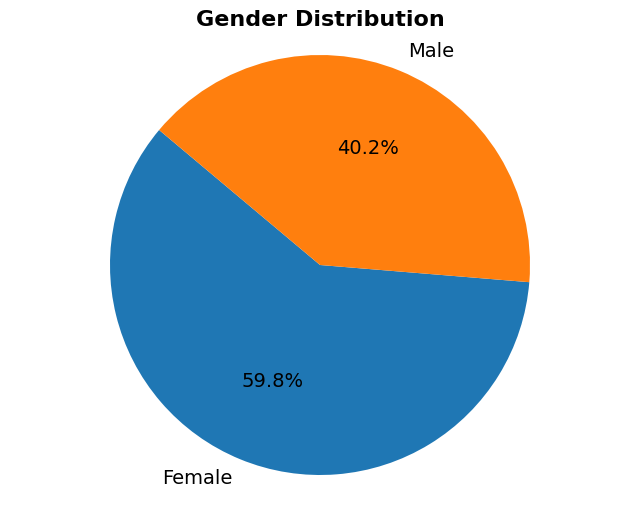

In [ ]:
plt.figure(figsize=(8, 6))
plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 14}
)

plt.title('Gender Distribution', fontweight='bold', fontsize=16)
plt.axis('equal')
plt.show()

Females make up ~60% of the customer base, outnumbering males by a notable margin across all malls.

## Time-Based Sales

In [7]:
sales_df['invoice_date'] = pd.to_datetime(sales_df['invoice_date'], format='%d/%m/%Y')

In [8]:
df_grouped = sales_df.groupby(['shopping_mall', 'invoice_date']).agg({'price': 'sum'}).reset_index()

In [9]:
df_dict_time_based = {mall: sub_df.drop(columns=['shopping_mall']) for mall, sub_df in df_grouped.groupby('shopping_mall')}

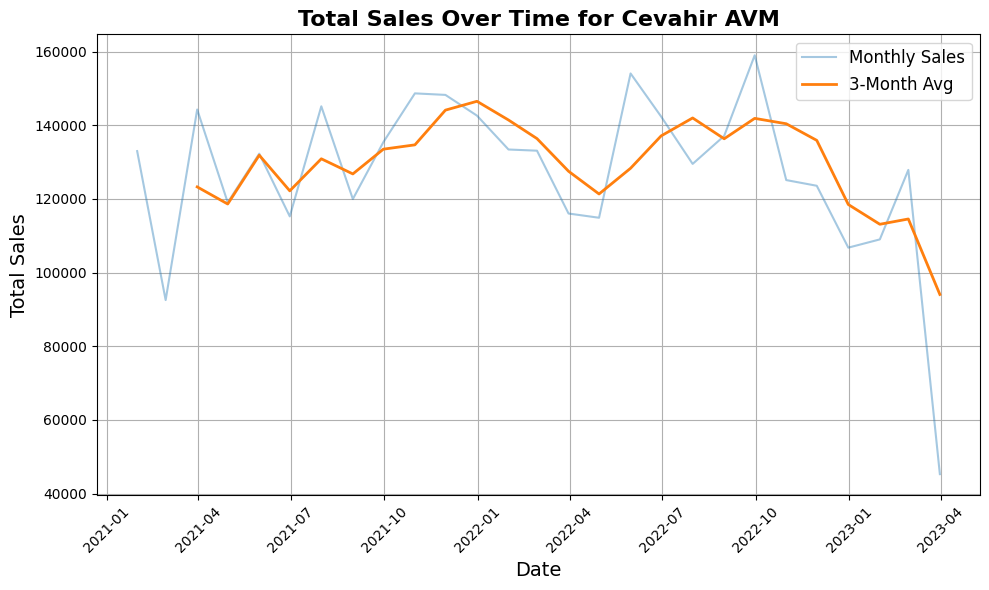

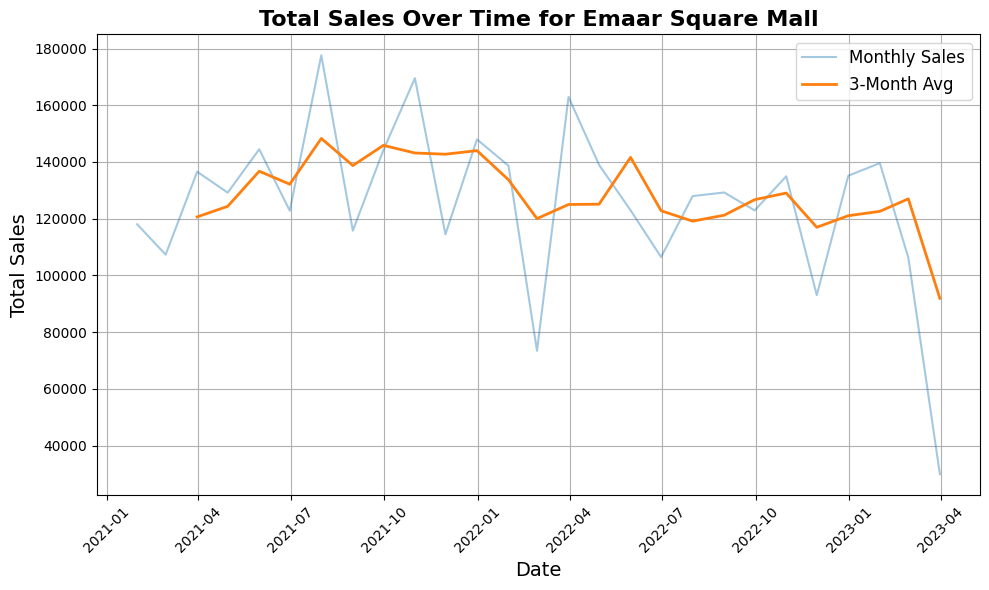

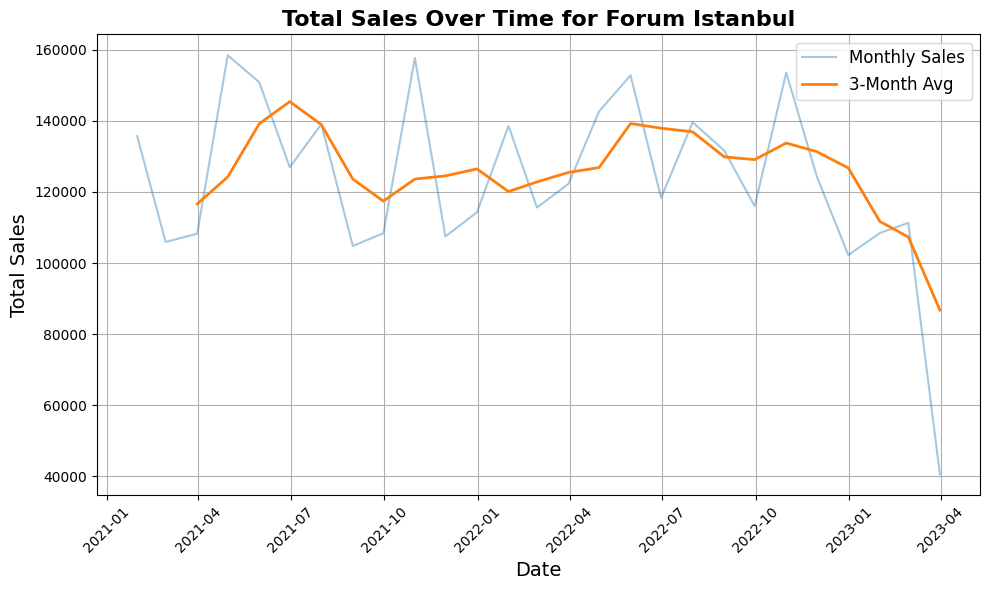

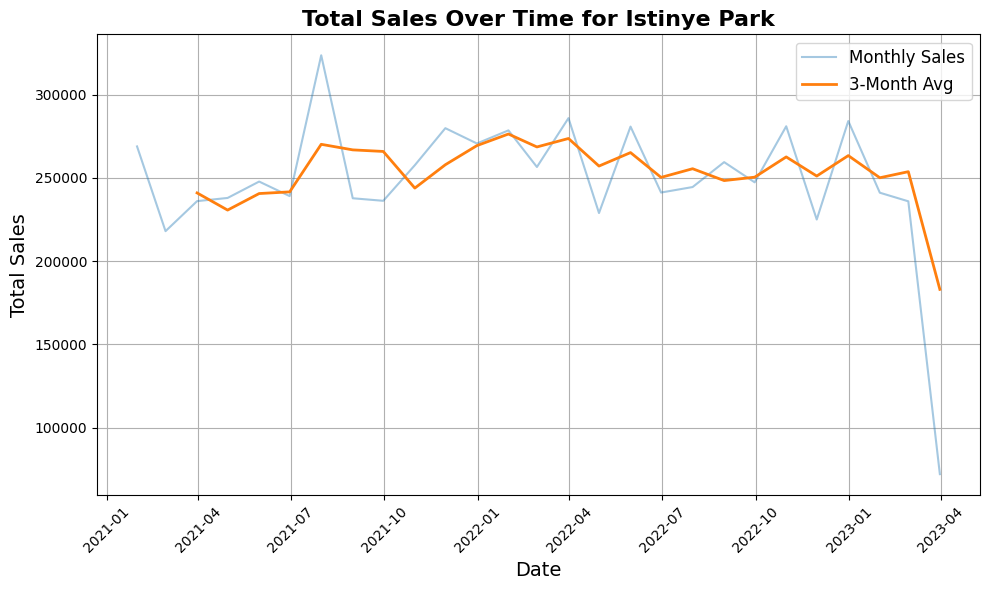

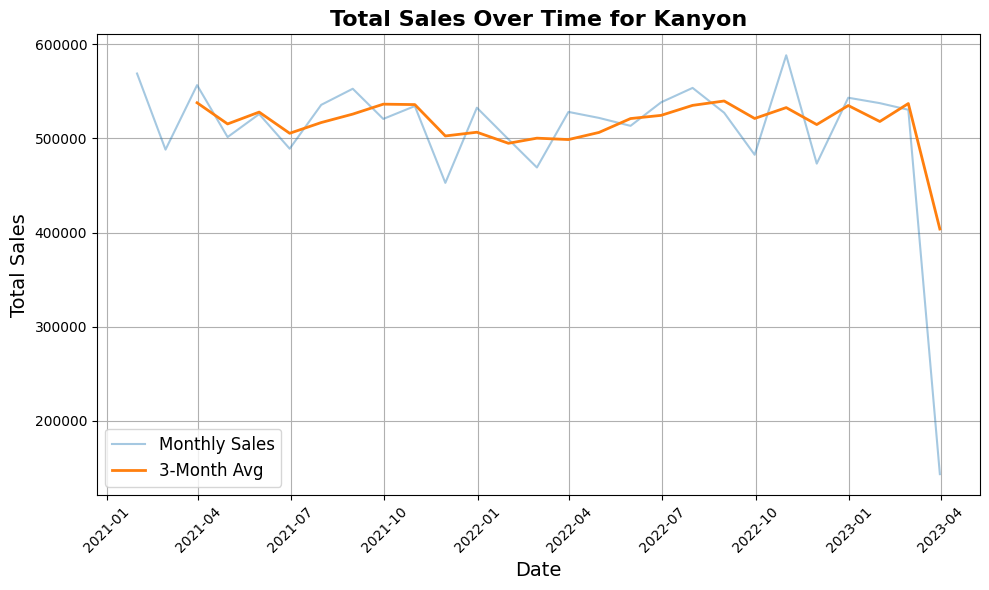

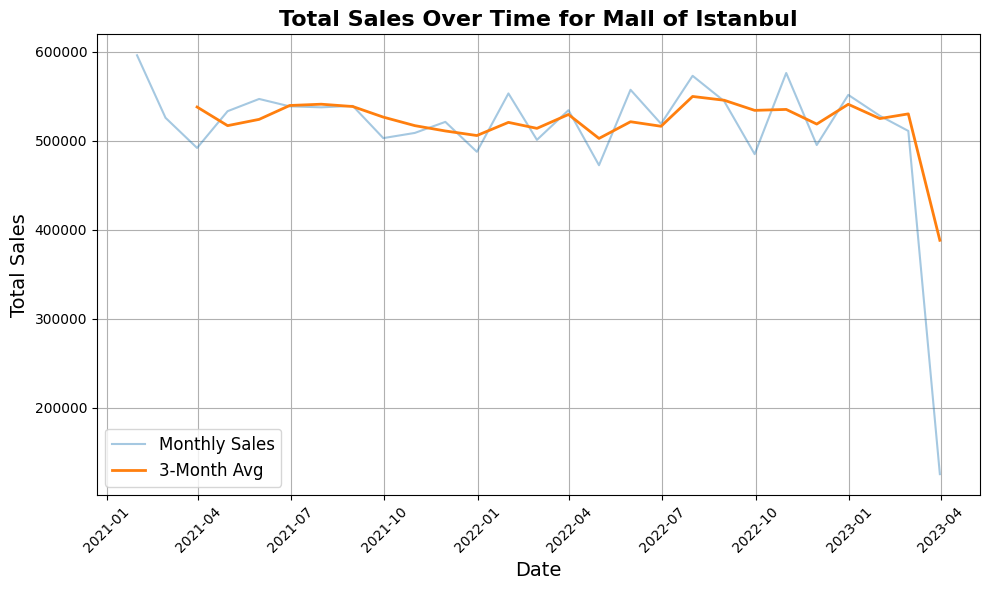

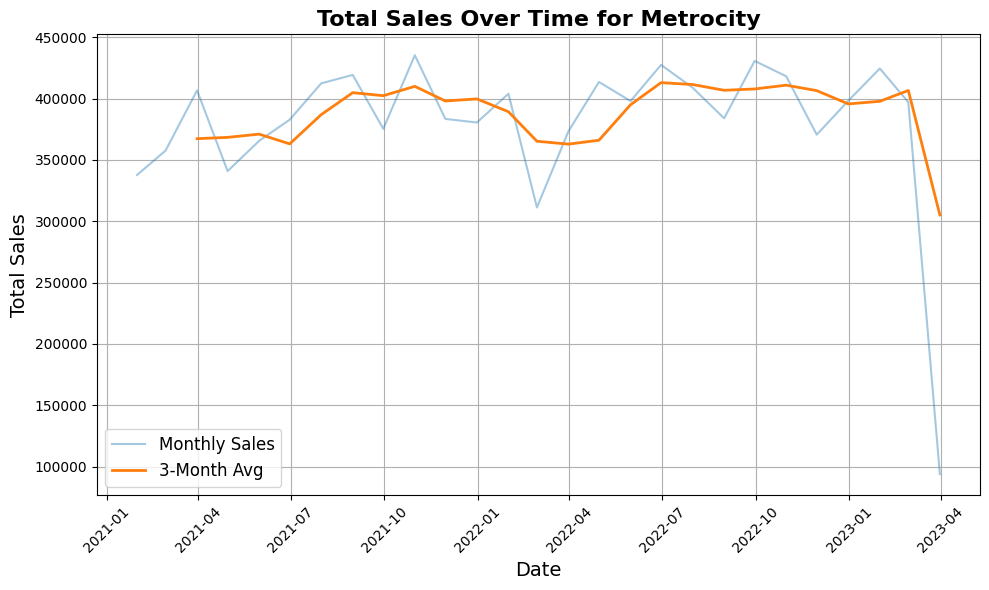

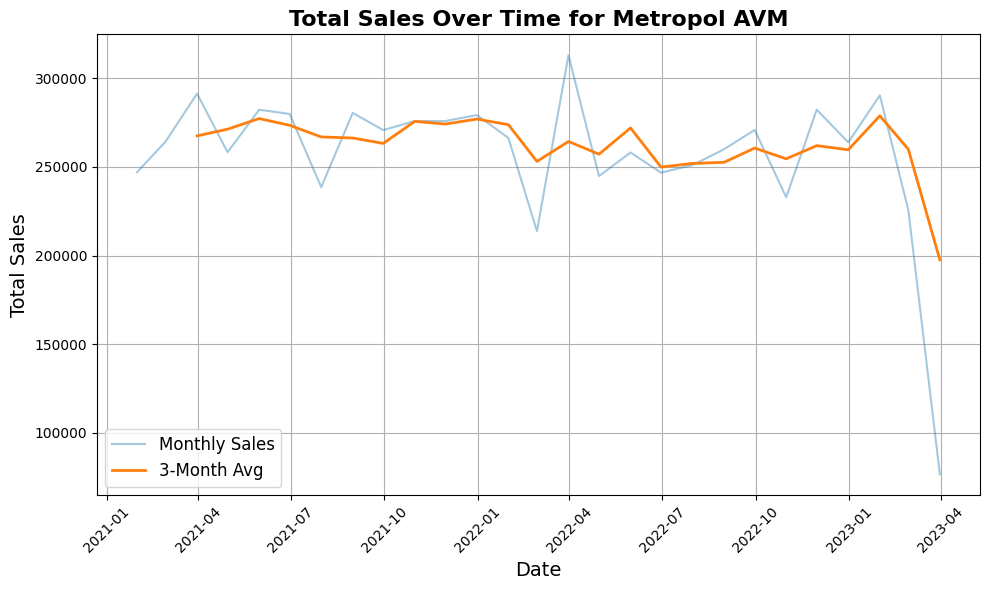

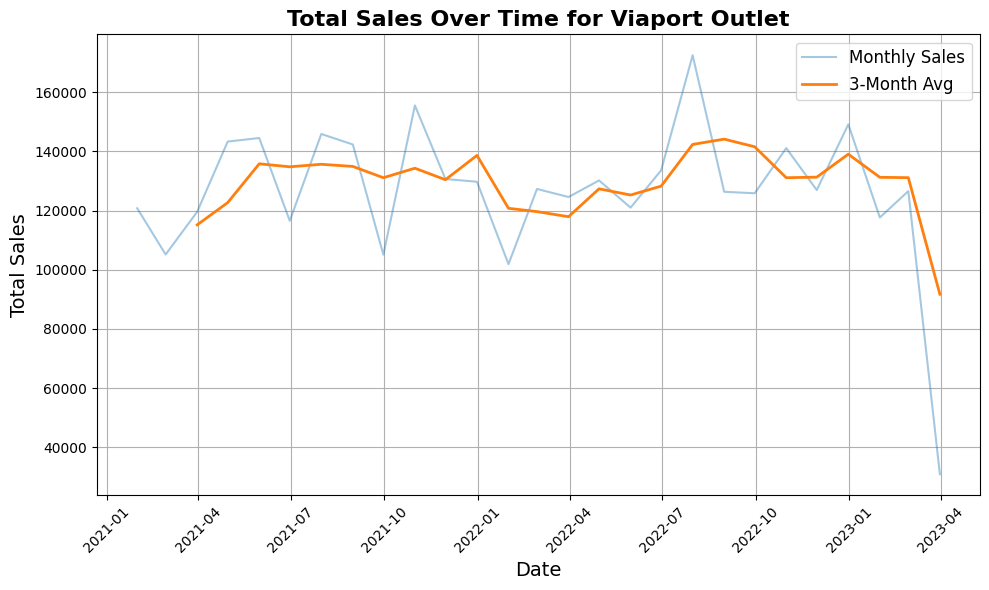

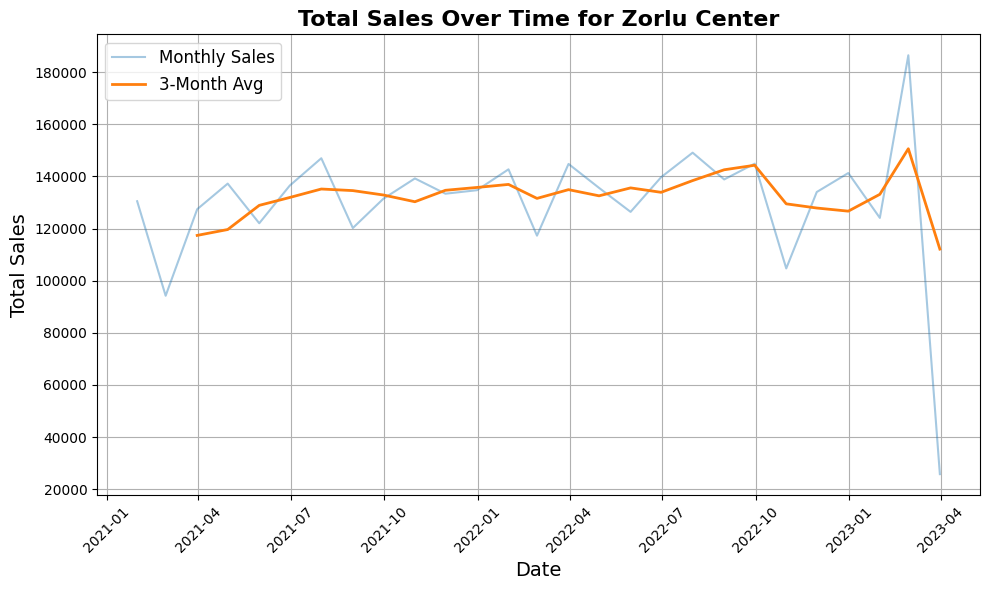

In [ ]:
for mall, df in df_dict_time_based.items():
    df = df.sort_values('invoice_date')
    df_monthly = df.resample('ME', on='invoice_date')['price'].sum().reset_index()
    
    plt.figure(figsize=(10, 6))
    plt.plot(df_monthly['invoice_date'], df_monthly['price'], alpha=0.4, label='Monthly Sales')
    plt.plot(df_monthly['invoice_date'], df_monthly['price'].rolling(3).mean(), linewidth=2, label='3-Month Avg')
    
    plt.title(f'Total Sales Over Time for {mall}', fontweight='bold', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Total Sales', fontsize=14)
    
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Sales remain stable across all 10 malls throughout 2021–2023 with no strong seasonal trend. 
The sharp drop at the end of each plot reflects incomplete data for the final month rather 
than an actual decline.

## Category Distribution

In [11]:
category_count = sales_df['category'].value_counts()
category_count

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

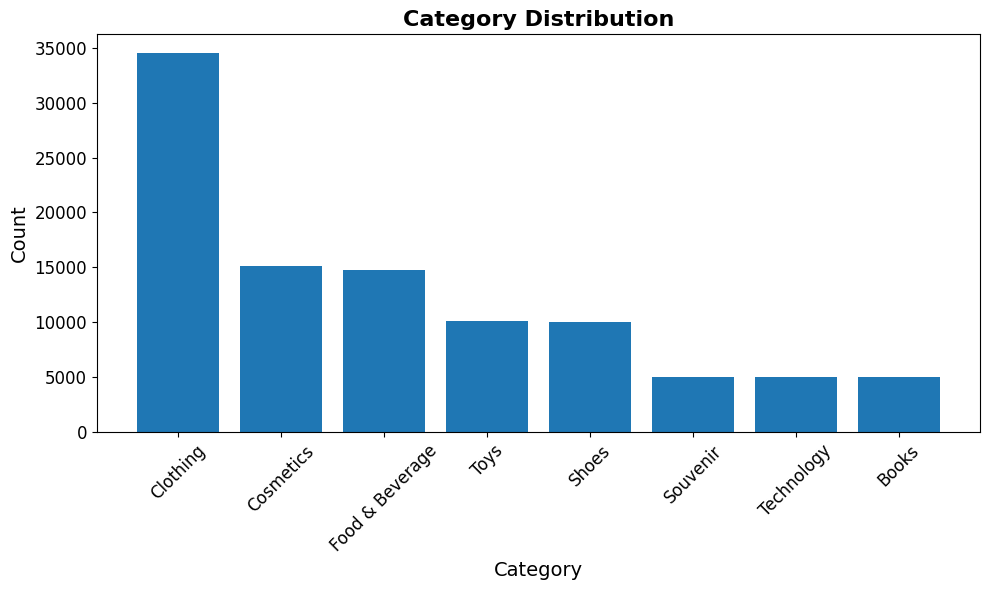

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(category_count.index, category_count.values)

plt.title('Category Distribution', fontweight='bold', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

Clothing leads by a wide margin with ~35,000 transactions, nearly double the next categories 
Cosmetics and Food & Beverage which sit around 15,000 each.

## Gender & Category

In [13]:
gender_count_per_category = sales_df.groupby(['gender', 'category']).size().unstack()

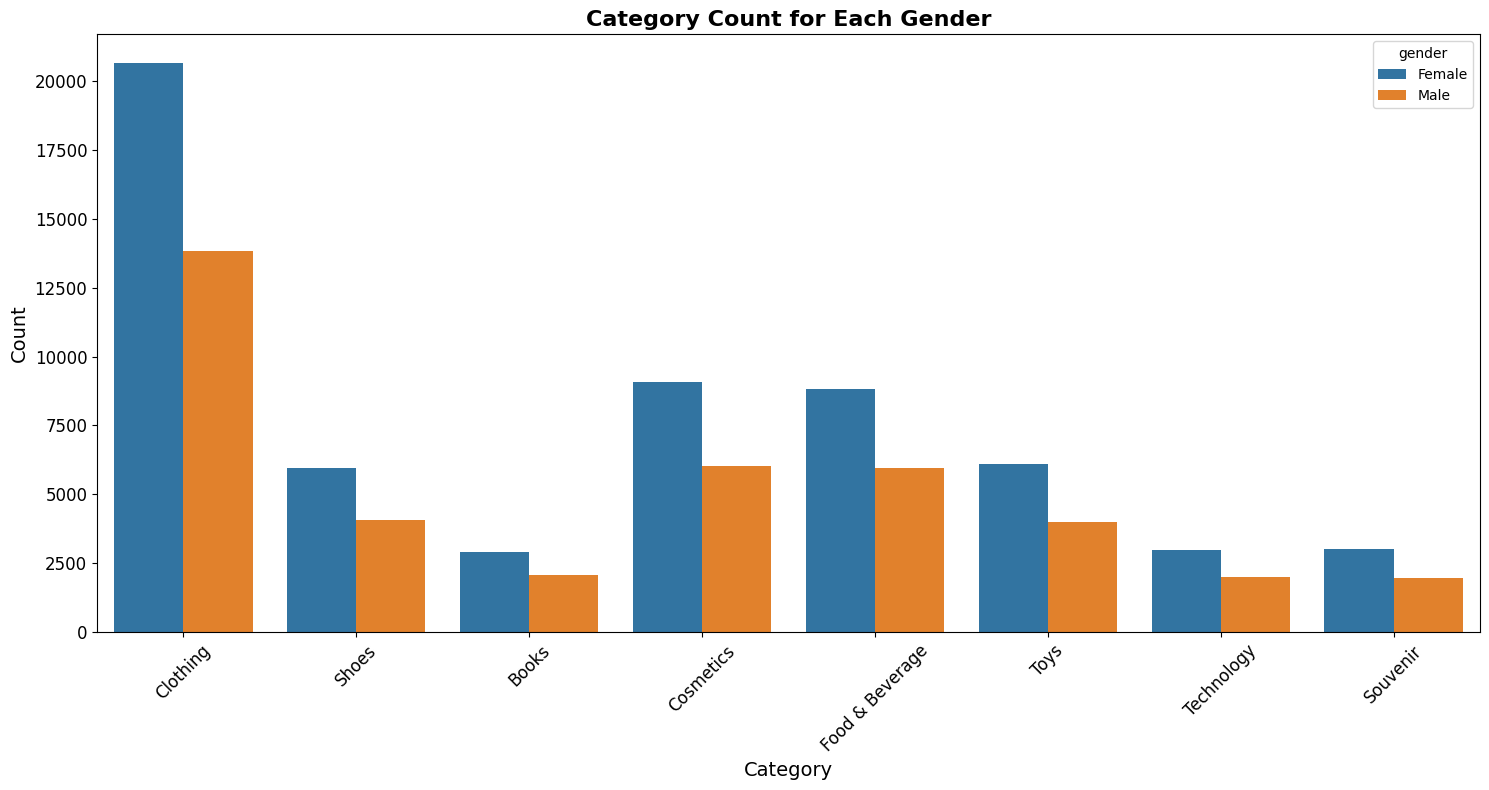

In [ ]:
plt.figure(figsize=(15, 8))
sns.countplot(data=sales_df, x='category', hue='gender')

plt.title('Category Count for Each Gender', fontweight='bold', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

Females outpurchase males in every category, most prominently in Clothing and Cosmetics. 
Males show relatively stronger presence only in Technology.

## Age Group Analysis

In [47]:
sales_df['age_group'] = pd.cut(
    sales_df['age'],
    bins=[0, 20, 30, 40, 50, 60, 70, 100],
    labels=['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+'],
    right=False
)

#### 9.1. Total Sales by Age Group 

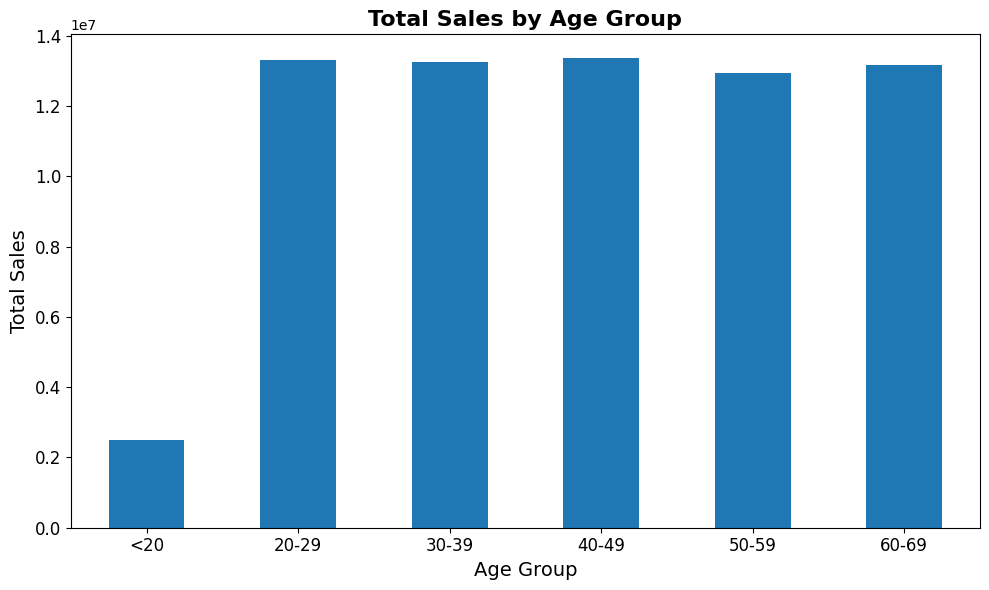

In [ ]:
age_sales = sales_df.groupby('age_group')['price'].sum()

plt.figure(figsize=(10, 6))
age_sales.plot(kind='bar')

plt.title('Total Sales by Age Group', fontweight='bold', fontsize=16)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

The <20 group contributes negligibly compared to all other age groups. From 20 onwards, 
spending is remarkably uniform across all age brackets with no single group dominating.

#### 9.2. Sales by Category for Each Age Group

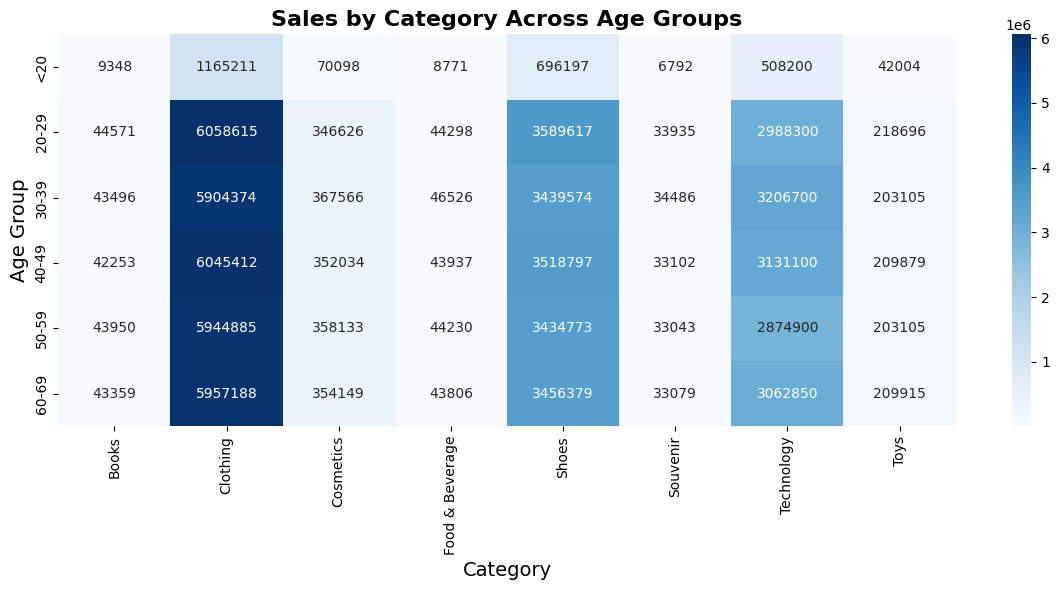

In [ ]:
age_category_sales = sales_df.pivot_table(
    index='age_group',
    columns='category',
    values='price',
    aggfunc='sum'
)

plt.figure(figsize=(12, 6))
sns.heatmap(age_category_sales, annot=True, fmt='.0f', cmap='Blues')

plt.title('Sales by Category Across Age Groups', fontweight='bold', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Age Group', fontsize=14)

plt.tight_layout()
plt.show()

Clothing and Shoes consistently generate the highest revenue across all age groups. 
The <20 group shows significantly lower absolute spending in every category.

#### 9.3. Gender Distribution Across Age Groups

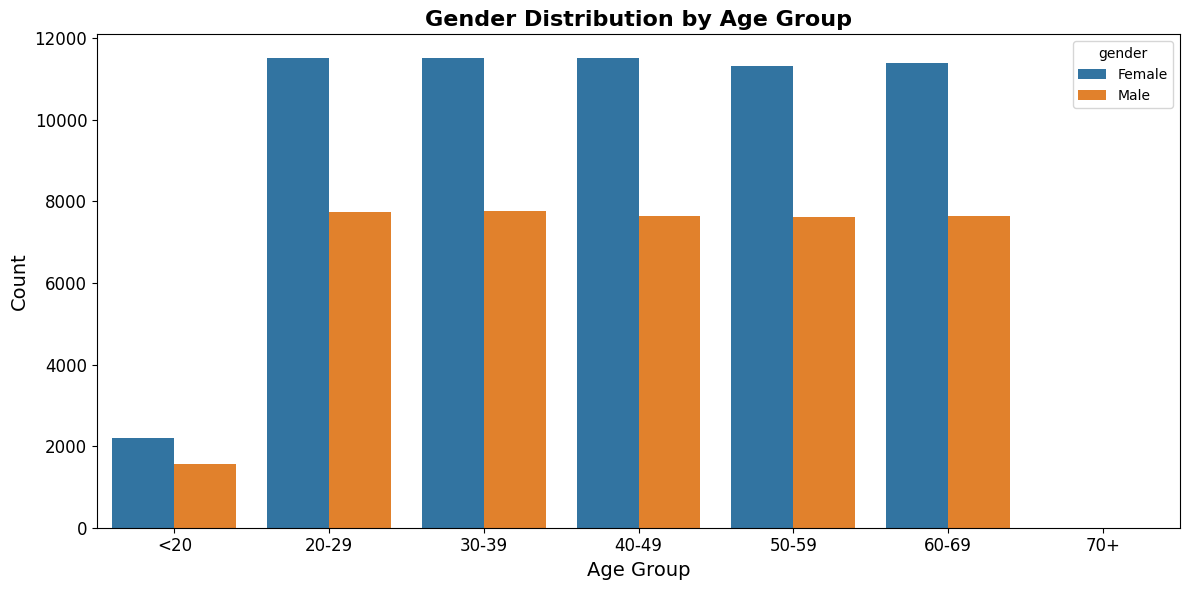

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=sales_df,
    x='age_group',
    hue='gender'
)

plt.title('Gender Distribution by Age Group', fontweight='bold', fontsize=16)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

The ~60/40 Female/Male split holds consistently across every age group, confirming it is 
a dataset-wide characteristic rather than specific to any demographic.

#### 9.4. Category + Gender Distribution Across Age Groups

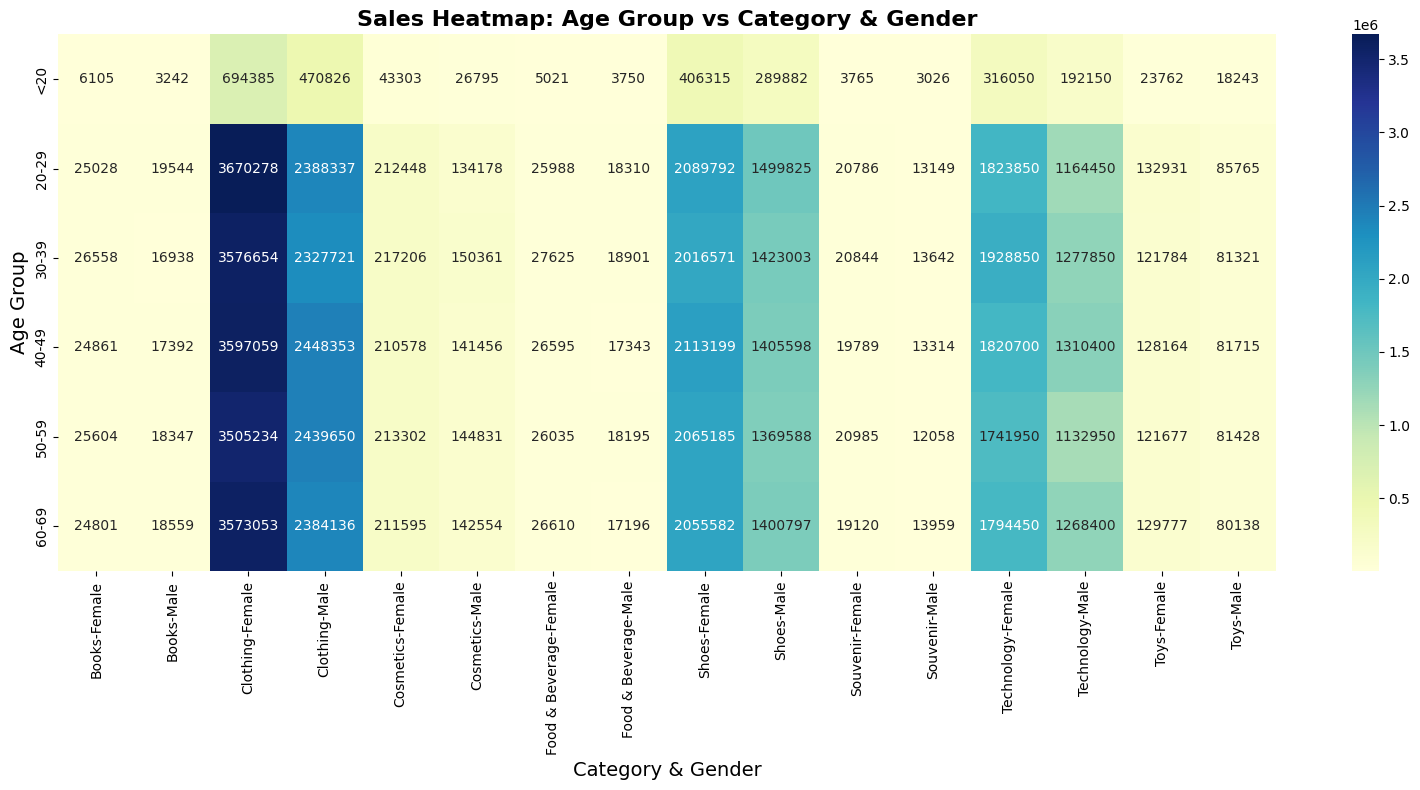

In [ ]:
age_gender_category = sales_df.pivot_table(
    index='age_group',
    columns=['category', 'gender'],
    values='price',
    aggfunc='sum'
)

plt.figure(figsize=(16, 8))
sns.heatmap(age_gender_category, annot=True, fmt='.0f', cmap='YlGnBu')

plt.title('Sales Heatmap: Age Group vs Category & Gender', fontweight='bold', fontsize=16)
plt.xlabel('Category & Gender', fontsize=14)
plt.ylabel('Age Group', fontsize=14)

plt.tight_layout()

plt.show()

Female Clothing purchases in the 20–49 range represent the highest-revenue micro-segment. 
Technology purchased by males aged 30–49 is the next strongest segment worth targeting.

## Key Insights

---

### Gender Distribution
Female customers make up the majority at approximately **60%**, while males account for **40%**. 
The customer base skews female, which should inform category stocking and promotional priorities.

---

### Category Distribution
**Clothing** is the dominant category by a significant margin, followed by **Shoes** and **Technology**. 
Categories like Books and Souvenir trail far behind, suggesting they serve niche demand rather than 
driving footfall.

---

### Gender & Category Preferences
Across nearly all categories, females outpurchase males — most notably in **Clothing and Cosmetics**. 
Males show relatively stronger presence in **Technology**. This gender-category split is consistent 
enough to justify gender-targeted promotions per category.

---

### Time-Based Sales Trends
All 10 malls show **no strong seasonal trend** — sales remain relatively flat across the observed 
period with irregular short-term fluctuations. No single mall shows a clear growth or decline 
trajectory, indicating a mature and stable retail market.

---

### Total Sales by Age Group
The **30–39** and **40–49** age groups generate the highest total revenue, making them the most 
commercially valuable segments. Sales drop noticeably below age 20 and above 60, suggesting 
limited engagement with younger and older demographics.

---

### Sales by Category Across Age Groups
**Clothing** dominates spending across all age groups. **Technology** spending peaks in the 
**30–49** range. Younger groups (<20, 20–29) show relatively lower absolute spending across all 
categories, likely reflecting lower purchasing power.

---

### Gender Distribution Across Age Groups
Gender balance (≈60/40 Female/Male) holds consistently across all age groups with no major 
deviation. This rules out age-specific gender skew as a factor — the split is a dataset-wide 
characteristic rather than demographic-specific.

---

### Multi-Dimensional Insights (Age × Category × Gender)
The combined heatmap confirms **Clothing purchased by females aged 30–49** as the single 
highest-revenue micro-segment across the dataset. **Technology purchased by males in the 30–49 
range** is the next notable segment. These two micro-segments represent the clearest targets for 
loyalty programs and premium placement strategies.